This notbook uses silhouette scores to identify elections for which 3-clustering is better than 2-clustering, and analyzes a few such elections.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import glob
from Clustering_Functions import *

In [2]:
filename_list = glob.glob("scot-elex/**/*.csv")
df = pd.DataFrame(columns=['filename', 'num_cands', 'sil'])

for filename in filename_list:
    num_cands, election, cand_names, location = csv_parse(filename)
    X = np.array([Borda_vector(ballot, num_cands=num_cands) for ballot in election.keys()])
    sample_weight = np.array([election[ballot] for ballot in election.keys()])

    sil_scores = []
    for k in range(2,6):
        kmeans = KMeans(n_clusters=k, n_init = 5).fit(X,sample_weight=sample_weight)
        labels = kmeans.labels_
        sil_scores.append(round(silhouette_score(X,labels),3))
    row_num = df.shape[0]
    if row_num%100 == 0:
        print(row_num)
    df.loc[row_num] = [filename, num_cands, tuple(sil_scores)]


0
100
200
300
400
500
600
700
800
900
1000


In [3]:
best_k = []
gap = []
for count in range(len(df)):
    sil = df['sil'][count]
    best_k.append(np.argmax(sil)+2)
    gap.append(sil[1]-sil[0])
df['best_k']=best_k
df['gap']=gap

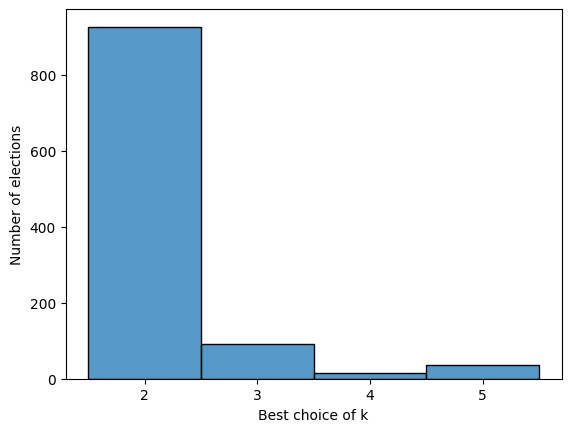

In [4]:
sns.histplot(data=df, x='best_k', binrange=(2,5), discrete=True)
plt.xticks([2, 3, 4, 5])
plt.xlabel('Best choice of k')
plt.ylabel('Number of elections')
plt.savefig("plots/best_k.jpg", dpi = 600)
plt.show()

In [5]:
df3 = df[df['best_k']==3]
len(df3)

92

<Axes: xlabel='num_cands', ylabel='Count'>

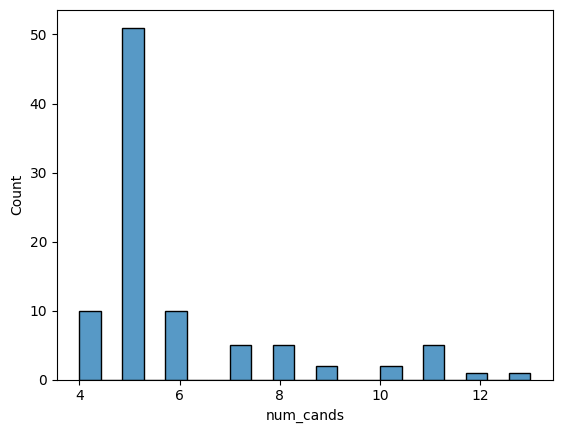

In [6]:
sns.histplot(data=df3, x='num_cands')

In [7]:
df[df['filename'].str.contains('edinburgh_2017_ward2')]

,filename,num_cands,sil,best_k,gap
549,scot-elex\7_cands\edinburgh_2017_ward2.csv,7,"(0.239, 0.177, 0.164, 0.152)",2,-0.062


In [9]:
from Clustering_Functions import kmeans

filename = 'scot-elex/7_cands/edinburgh_2017_ward2.csv'
num_cands, election, cand_list, ward = csv_parse(filename)
parties = party_abrevs(cand_list)
C = kmeans(election, k=3)

In [10]:
# Need to re-write the Ballot_MDS_plot function to ouptut two images, 
# one colored by cluster assignment and the other by the party of the first place vote.

def Ballot_MDS_plot_2(election, clusters = None, num_cands = 'Auto', proxy='Borda', borda_style='pes', threshold=10, 
                    label_threshold = np.infty, metric = 'Euclidean', party_names=None, filename=None, dpi = 600):
    """
    Displays an MDS (multi-dimensional scaling) plot for the proxies of all of the ballots in the election that received at least the given threshold number of votes.
    If clusters is provided, they are colored by their cluster assignments; otherwise, by party of 1st place vote.
    
    Args:
        election : a dictionary matching ballots to weights.
        clusters : (optional) a clustering (list of elections that partitions the given election.)
        proxy : choice of {'Borda', 'HH'} for Borda or head-to-head proxy vectors.
        borda_style : choice of {'pes', 'avg'}, which is passed to Borda_vector (only used if proxy == 'Borda') 
        threshold : it ignores all ballots that were cast fewer than the threshold number of times.
        label_threshold : it labels all ballots that were cast at least the label_threshold number of times (set label_threshold=np.infty for no labeling)
        metric : choice of {'Euclidean', 'Manhattan'} for the proxy metric that's approximated.
        party_names : if provided, it will color by party of first place vote.
        filename : to save the plot.   
    """

    if num_cands == 'Auto':
        num_cands = max([item for ranking in election.keys() for item in ranking])

    ballots = []
    proxies = []
    weights = []
    colors_party = []
    colors_cluster = []
    cluster_assignments = []

    if clusters == None:
        clusters = [election]

    for cluster_num in range(len(clusters)):
        cluster = clusters[cluster_num]
        start_index = len(proxies)
        for ballot,weight in cluster.items():
            if weight>=threshold:
                if proxy=='Borda':
                    ballot_proxy = Borda_vector(ballot,num_cands=num_cands, borda_style=borda_style)
                else:
                    ballot_proxy = HH_proxy(ballot,num_cands=num_cands)
                ballots.append(ballot)
                proxies.append(ballot_proxy)
                weights.append(weight)
                cluster_assignments.append(cluster_num)
                if party_names != None:
                    D = {'SNP':'yellow', 'Lab': 'red', 'Con':'blue','LD':'orange','Gr':'green'}
                    party = party_names[ballot[0]-1]
                    colors_party.append(D[party] if party in D.keys() else 'black')

    if metric == 'Euclidean':
        similarities = euclidean_distances(proxies)
    else:
        similarities = manhattan_distances(proxies)

    projections = MDS(n_components=2, dissimilarity='precomputed').fit_transform(similarities)
    X = np.array([p[0] for p in projections])
    Y = np.array([p[1] for p in projections])

    palat = ['grey','purple','tomato','orange','b','c','g', 'r', 'm', 'y']
    if len(clusters)>1:
        colors_cluster = [palat[x] for x in cluster_assignments]

    # plot with party colors
    fig, ax = plt.subplots()
    ax.scatter(X,Y, s = weights, c = colors_party, alpha = .5)
    ax.grid(False)
    ax.axis('off')
    x_margin = (max(X) - min(X)) * 0.2  # 20% margin
    y_margin = (max(Y) - min(Y)) * 0.2  # 20% margin
    plt.xlim(min(X) - x_margin, max(X) + x_margin)
    plt.ylim(min(Y) - y_margin, max(Y) + y_margin)
    for count in range(len(proxies)):
        if weights[count]>label_threshold:
            ax.annotate(ballots[count], xy=(X[count], Y[count]))
    plt.savefig('plots\PH3_parties', dpi = dpi)
    
    #plot with cluster colors
    fig, ax = plt.subplots()
    ax.scatter(X,Y, s = weights, c = colors_cluster, alpha = .5)
    ax.grid(False)
    ax.axis('off')
    x_margin = (max(X) - min(X)) * 0.2  # 20% margin
    y_margin = (max(Y) - min(Y)) * 0.2  # 20% margin
    plt.xlim(min(X) - x_margin, max(X) + x_margin)
    plt.ylim(min(Y) - y_margin, max(Y) + y_margin)
    for count in range(len(proxies)):
        if weights[count]>label_threshold:
            ax.annotate(ballots[count], xy=(X[count], Y[count]))
    plt.savefig('plots\PH3_clusters', dpi = dpi)


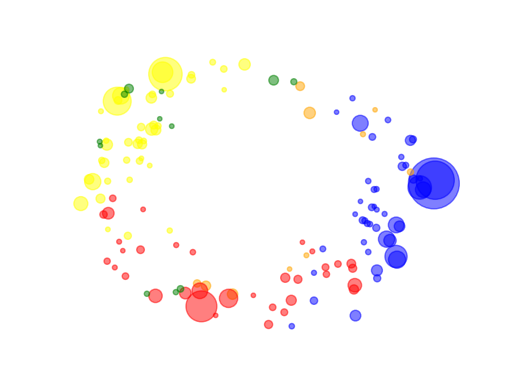

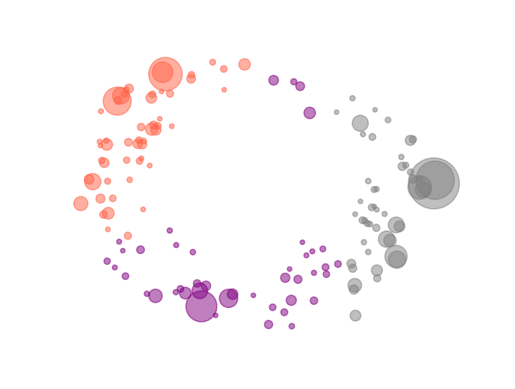

In [11]:
Ballot_MDS_plot_2(election, clusters=C,  party_names=parties, threshold=10)